<a href="https://colab.research.google.com/github/HRashidLiaquat/lessons-learned/blob/Animal_CRNN/Animal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Workflow Work**
1. IMPORT IMPORTANT LIBRARIES
2. GET DATA READY IN KAGGLE
3. PREPARING DATA
4. LOADING TRAINING IMAGES
5. DATA LOADERS
6. CUSTOM CNN LAYERS (Feature Extraction from Scratch)
7. RNN LAYERS (Recurrent Encoding)
8. BUILD PURE CRNN MODEL (FROM SCRATCH)
9. MODEL TRAINING
10. MODEL TESTING (TRAINING LOOP)
11. MODEL EVALUATION
12. TESTING WITH NEW DATA POINT
13. SAVE MODEL

**IMPORT IMPORTANT LIBRARIES**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from pathlib import Path
from tqdm import tqdm
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
import zipfile
import random

**Mount GDrive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Zip to unzip**

In [4]:
zip_path = Path("/content/drive/MyDrive/Colab Notebooks/Animalgoatdataset.zip")
extract_path = Path("/content/data")

print("ZIP exists:", zip_path.exists())

extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

ZIP exists: True


In [5]:
datset_path = Path('/content/data/Animalgoatdataset')

if datset_path.exists():
  print("Dataset found!")
else:
  print("Dataset not found!")

Dataset found!


In [6]:
if datset_path.exists():
  datsetfolderlist = list(datset_path.iterdir())
  print("See all folder in my dataset main folder")
  for allfolder in datsetfolderlist:
      print(allfolder)

See all folder in my dataset main folder
/content/data/Animalgoatdataset/test
/content/data/Animalgoatdataset/train


**Check Animal data**

In [7]:
traning_path = datset_path / '/content/data/Animalgoatdataset/train'
print(traning_path)
# test_path = datset_path / '/content/data/Animalgoatdataset/test'
train_classes = [item.name for item in traning_path.iterdir() if item.is_dir()]
train_classes.sort()
num_classes = len(train_classes)
print(f"Total animal data: {num_classes}")

/content/data/Animalgoatdataset/train
Total animal data: 2


**Display goat Raw data**

In [8]:
dataset_path = Path('/content/data/Animalgoatdataset')

train_path = dataset_path / 'train'
test_path = dataset_path / 'test'

print("Train classes:", [f.name for f in train_path.iterdir() if f.is_dir()])
print("Test classes:", [f.name for f in test_path.iterdir() if f.is_dir()])

Train classes: ['unhealthy_goat', 'healthy_goat']
Test classes: ['unhealthy_goat', 'healthy_goat']


In [9]:
from torchvision import datasets

raw_train_dataset = datasets.ImageFolder(
    train_path,
    transform=None
)

print("Total raw train images:", len(raw_train_dataset))
print("Classes:", raw_train_dataset.classes)

Total raw train images: 742
Classes: ['healthy_goat', 'unhealthy_goat']


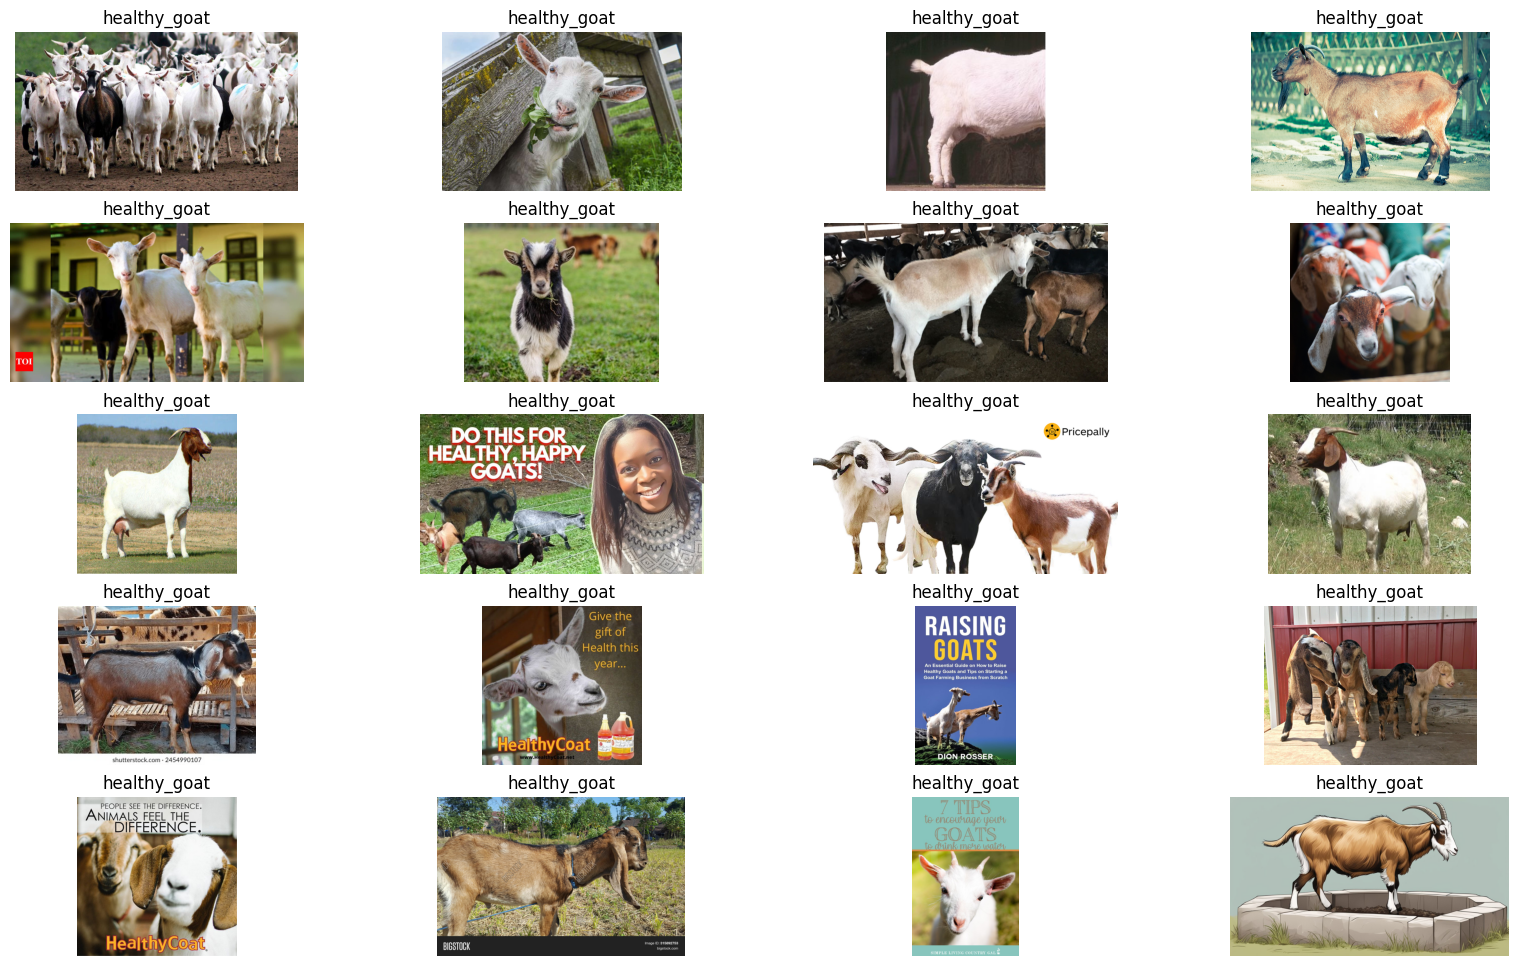

In [10]:
plt.figure(figsize=(20,12))

for i in range(20):
    img, label = raw_train_dataset[i]
    plt.subplot(5, 4, i+1)
    plt.imshow(img)
    plt.title(raw_train_dataset.classes[label])
    plt.axis("off")

plt.show()

**Data Preprocessing**

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])


In [12]:
train_transform, test_transform

(Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     ToTensor()
     Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
 ),
 Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
 ))

**Load Dataset**

In [13]:
train_path = "/content/data/Animalgoatdataset/train"
test_path  = "/content/data/Animalgoatdataset/test"

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            return img.mode == 'RGB'
    except (IOError, UnidentifiedImageError):
        return False

train_dataset = datasets.ImageFolder(train_path, transform=train_transform, is_valid_file=is_valid_image)
test_dataset  = datasets.ImageFolder(test_path, transform=test_transform, is_valid_file=is_valid_image)

print("Classes:", train_dataset.classes)
print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))

Classes: ['healthy_goat', 'unhealthy_goat']
Train images: 706
Test images: 179


**Create DataLoaders**

In [14]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

**Visualize One Batch data**

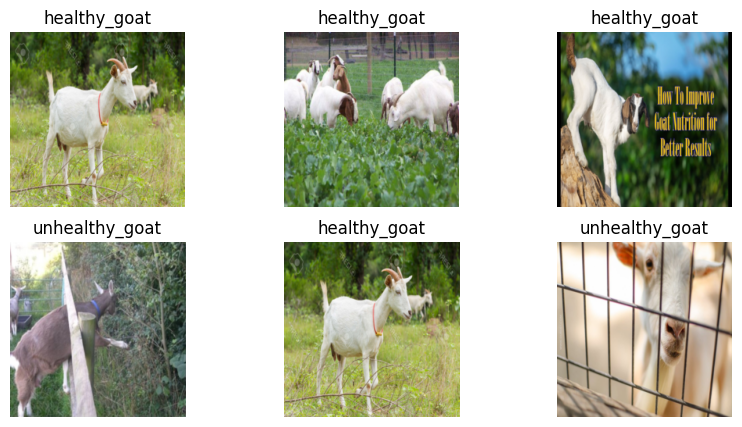

In [15]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0)*0.5 + 0.5)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()


**Model Bulding CRNN**

In [16]:
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.rnn = nn.LSTM(
            input_size=64*56,
            hidden_size=128,
            batch_first=True
        )

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0,3,1,2)
        x = x.reshape(x.size(0), x.size(1), -1)
        x, _ = self.rnn(x)
        x = self.fc(x[:,-1,:])
        return x


**Create model Object**

In [17]:
model = CRNN(num_classes)

In [18]:
model

CRNN(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (rnn): LSTM(3584, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

**Define Loss**

In [19]:
criterion = nn.CrossEntropyLoss()

In [20]:
criterion

CrossEntropyLoss()

**Define Optimizer**

In [21]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [22]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

**Device move to cpu to gpu**

In [23]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model moved to: {device}")

Model moved to: cuda


**Traning Loop**

In [26]:
num_epochs = 2
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0

    # Progress bar for batches within each epoch
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}',
                      unit='batch', leave=True)

    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images);
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

        current_acc = (correct / ((train_pbar.n + 1) * train_loader.batch_size)) * 100
        train_pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{current_acc:.2f}%'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = (correct / len(train_dataset)) * 100

    # Accuracy
    print(f'Epoch {epoch+1}/{num_epochs} Summary:')
    print(f'  Average Loss: {epoch_loss:.4f}')
    print(f'  Accuracy: {epoch_acc:.2f}%')


Epoch 1/2: 100%|██████████| 45/45 [00:21<00:00,  2.13batch/s, Loss=0.0623, Acc=87.92%]


Epoch 1/2 Summary:
  Average Loss: 0.2473
  Accuracy: 89.66%


Epoch 2/2: 100%|██████████| 45/45 [00:20<00:00,  2.21batch/s, Loss=0.5073, Acc=91.11%]

Epoch 2/2 Summary:
  Average Loss: 0.1860
  Accuracy: 92.92%


**Save model accuracy**

In [28]:
save_path = "/content/animal_model.pth"

torch.save({
    "model_state": model.state_dict(),
    "accuracy": epoch_acc
}, save_path)

print(f'  Accuracy: {epoch_acc:.2f}%')

  Accuracy: 92.92%
